In [ ]:
!pip install ott-jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.7/283.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.4 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.4.33
    Uninstalling jaxlib-0.4.33:
      Successfully uninstalled jaxlib-0.4.33
  Attempting uninstall: jax
    Found existing installation: jax 0.4.33
    Uninstalling jax-0.4.33:
      Successfully uninstalled jax-0.4.33


In [ ]:
from functools import partial

import jax
import jax.flatten_util
from jax import random
from jax import numpy as jnp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from google.colab import files
import pickle
from scipy.stats import wasserstein_distance_nd
from ott.geometry import pointcloud
from ott.solvers import linear

rerun: bool = False


def mmd(X, Y, h = 1.):
    def kernel(x, y):
        return jnp.exp(-jnp.sum((x - y) ** 2) / (2 * h ** 2))
    def gram(X, Y):
        return jax.vmap(lambda x_i: jax.vmap(lambda y_i: kernel(x_i, y_i))(Y))(X)
    def remove_diagonal(x):
        return x[~jnp.eye(x.shape[0], dtype=bool)].reshape(x.shape[0], -1)
    xx = gram(X, X)
    xy = gram(X, Y)
    yy = gram(Y, Y)
    return (
        jnp.mean(remove_diagonal(xx))
        + jnp.mean(remove_diagonal(yy))
        - 2 * jnp.mean(xy)
    )

def optimal_score(x, samples, sigma, mu):
    m_exponents = jnp.exp(
        -jnp.sum((-(x - mu * samples) ** 2 / (2 * (sigma ** 2))), axis=1, keepdims=True) +
        jnp.sum((-(x - mu * samples) ** 2 / (2 * (sigma ** 2))), axis=1)
    )
    exponents = jnp.sum(m_exponents, axis=1, keepdims=True)
    nominator = mu * samples / exponents
    return jnp.sum(nominator, axis=0) / (sigma ** 2) - x / (sigma ** 2)
batch_optimal_score = jax.vmap(optimal_score, in_axes=[0, None, None, None])

# Toy example with dataset generated by Gaussian
def generate_dataset(d, dataset_size, deviation, key = None):
    if key is None: key = random.key(0)
    subkey = random.split(key, 2)[0]
    X = deviation * random.normal(subkey, shape=(dataset_size, d))
    return X

In [ ]:
def two_layer_nn_diffusion(params, x, t):
    w_1, w_2, b = params
    X = jnp.concat([x, t])
    m = w_1.shape[0]
    return 1 / m * w_2 @ jax.nn.relu(w_1 @ X + b)
batch_two_layer_nn_diffusion = jax.vmap(two_layer_nn_diffusion, in_axes=[None, 0, 0])
def init_params_diffusion(d, m, key):
    subkeys = random.split(key, 2)
    w_1 = random.normal(subkeys[0], (m, d+1)) / jnp.sqrt(d+1)
    w_2 = random.normal(subkeys[1], (d, m))
    b = jnp.zeros((m, ))
    return (w_1, w_2, b)

@jax.jit
def risk_fn_diffusion(params, samples, t, key):
    noise = random.normal(key, shape = samples.shape)
    mu = jnp.exp(-2 * t)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    y = mu * samples + sigma * noise
    return jnp.mean((batch_two_layer_nn_diffusion(params, y, t) - noise)**2)

grad_fn_diffusion = jax.value_and_grad(risk_fn_diffusion, argnums=0)

@partial(jax.jit, static_argnames=["batch_size", "m"])
def sgd_step_diffusion(params, full_dataset, batch_size, key, master_step_size, m, delta = 0.05):
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    subkeys = random.split(key, 3)
    batch = random.choice(subkeys[0], full_dataset, shape=(batch_size, ))
    batch_X = batch[:, :]
    sigmas = 1 / jnp.sqrt(1-jnp.exp(-2 * timesteps))
    batch_t = random.choice(subkeys[1], timesteps, shape=(batch_size, 1), p = sigmas/jnp.sum(sigmas) )
    risk, grad = grad_fn_diffusion(params, batch_X, batch_t, subkeys[2])
    W_1 = params[0] - m * master_step_size * grad[0]
    w_2 = params[1] - m * master_step_size * grad[1]
    b = params[2] - m * master_step_size * grad[2]
    return (W_1, w_2, b), risk

def training_loop_diffusion(dataset_size, batch_size, n_steps, step_size, m, d = 2, delta = 0.05, deviation = 1, key = None):
    if key is None: key = random.key(0)
    subkeys = random.split(key, 3)
    dataset = generate_dataset(d, dataset_size, deviation, subkeys[0])
    params = init_params_diffusion(d, m, subkeys[1])
    subkeys_sgd = random.split(subkeys[2], n_steps)
    timesteps = jnp.linspace(delta, 1.0, 100)
    loss_hist = [0]*n_steps
    for step in tqdm(range(n_steps)):
        params, risk = sgd_step_diffusion(params, dataset, batch_size, subkeys_sgd[step], step_size, m)
        loss_hist[step] = risk
    return loss_hist, params, dataset

In [ ]:
def generate_OU_nn(params, n_samples = 500, delta = 0.05, key = None):
    d = params[1].shape[0]
    print('Start generating samples with nn...')
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    dt = timesteps[0] - timesteps[1]
    if key is None: key = random.key(0)
    subkeys = random.split(key, 2)
    samples = random.normal(subkeys[0], shape=(n_samples, d))
    subkeys_noise = random.split(subkeys[1], len(timesteps))
    with tqdm(total=len(timesteps)) as pbar:
        for i, t in enumerate(timesteps):
            dW = random.normal(subkeys_noise[i], shape=(n_samples, d))
            t_np = jnp.array([t]*n_samples).reshape(n_samples, 1)
            score_value = - 1/jnp.sqrt(1 - jnp.exp(-2 * t_np)) * batch_two_layer_nn_diffusion(params, samples, t_np)
            samples = samples + samples * dt + 2 * score_value * dt + jnp.sqrt(2 * dt) * dW
            pbar.update(1)
    return samples

def generate_OU_optimal(dataset, n_samples = 500, delta = 0.05, key = None):
    d = dataset.shape[1]
    print(f'dimension={d}')
    print('Start generating samples with optimal score...')
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    dt = timesteps[0] - timesteps[1]
    if key is None: key = random.key(0)
    subkeys = random.split(key, 2)
    samples = random.normal(subkeys[0], shape=(n_samples, d))
    subkeys_noise = random.split(subkeys[1], len(timesteps))
    with tqdm(total = len(timesteps)) as pbar:
        for i, t in enumerate(timesteps):
            dW = random.normal(subkeys_noise[i], shape=(n_samples, d))
            mu = jnp.exp(-2 * t)
            sigma = jnp.sqrt(1-jnp.exp(-2 * t))
            score_value = jnp.nan_to_num(batch_optimal_score(samples, dataset, sigma, mu))
            # print(f'{jnp.sum(jnp.isnan(score_value))}')
            samples = samples + samples * dt + 2 * score_value * dt + jnp.sqrt(2 * dt) * dW
            pbar.update(1)
    return samples

def generate_optimal(dataset, n_samples=100, delta=0.01, key=None):
    if key is None: key = random.key(0)
    subkeys = random.split(key, dataset.shape[0])
    s = []
    for i in range(dataset.shape[0]):
        s.append(dataset[i]+jnp.sqrt(1-jnp.exp(-2*delta))*
                 random.normal(subkeys[i], shape=(n_samples, dataset.shape[1])))
    return jnp.vstack(s)

In [ ]:
from ott import utils
import numpy as np
def compute_dist(dist_list, n_samples = 1000, h=.1, dist = 'mmd'):
    key = random.key(42)
    rng = np.random.default_rng()
    subkeys_dim = random.split(key, len(dist_list))
    solve_fn = jax.jit(linear.solve)
    res_dict = {
        'lr': dist_list[0]['lr'],
        'dist': dist,
        'dim': [],
        'dist_optimal': [],
        'dist_true': [],
        'true_optimal': [],
        'dist_optimal_proportion': [],
        'dist_true_proportion': []
    }
    for i, d in enumerate(dist_list):
        print(f'Dimension = {d["dim"]}')
        subkeys = random.split(subkeys_dim[i], len(d["samples"]))
        for j, sample in enumerate(d["samples"]):
            res_dict["dim"].append(d["dim"])
            sk = random.split(subkeys[j], 5)
            print(f'Round {j+1}')
            samples_true = jnp.array(
                rng.multivariate_normal(
                np.array(jnp.mean(d['dataset'], axis=0)),
                np.array(jnp.cov(d['dataset'].T)),
                size = (n_samples,),
                method = 'svd'
            ))
            samples_optimal = generate_OU_optimal(d['dataset'], n_samples, delta=delta, key = subkeys[j])
            # samples_optimal = generate_optimal(d["dataset"], delta=d['delta'], key=sk[1])
            assert dist in [
                'mmd',
                'wasserstein'
            ]
            if dist == 'mmd':
                dist_true = float(mmd(sample, samples_true, h))
                dist_optimal = float(mmd(sample, samples_optimal, h))
                dist_true_optimal = float(mmd(samples_true, samples_optimal, h))
            elif dist == 'wasserstein':
                geom = pointcloud.PointCloud(sample, samples_true, epsilon=.01)
                ot = solve_fn(geom)
                dist_true = float(ot.primal_cost)
                print(f'{ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
                geom = pointcloud.PointCloud(sample, samples_optimal, epsilon=.01)
                ot = solve_fn(geom)
                dist_optimal = float(ot.primal_cost)
                print(f'{ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
                geom = pointcloud.PointCloud(samples_true, samples_optimal, epsilon=.01)
                ot = solve_fn(geom)
                dist_true_optimal = float(ot.primal_cost)
                print(f'{ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            print(f'Distance to true distribution:    {dist_true:.5g}')
            print(f'Distance to optimal distribution: {dist_optimal:.5g}')
            print(f'Distance true to optimal:         {dist_true_optimal:.5g}')
            res_dict["dist_optimal"].append(dist_optimal)
            res_dict["dist_true"].append(dist_true)
            res_dict["true_optimal"].append(dist_true_optimal)
            res_dict["dist_optimal_proportion"].append(dist_optimal / dist_true_optimal)
            res_dict["dist_true_proportion"].append(dist_true / dist_true_optimal)
    return res_dict

100%|██████████| 20000/20000 [00:21<00:00, 912.33it/s] 


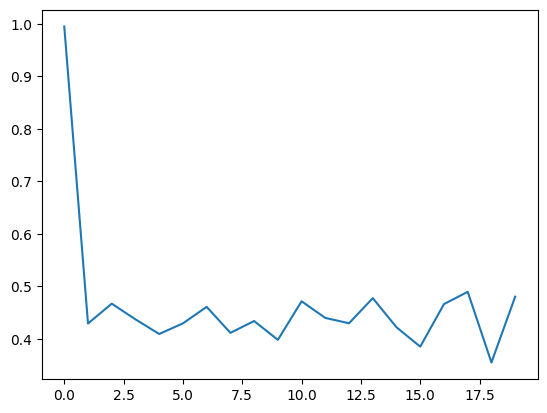

Start generating samples with nn...


100%|██████████| 100/100 [00:15<00:00,  6.58it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 74.49it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

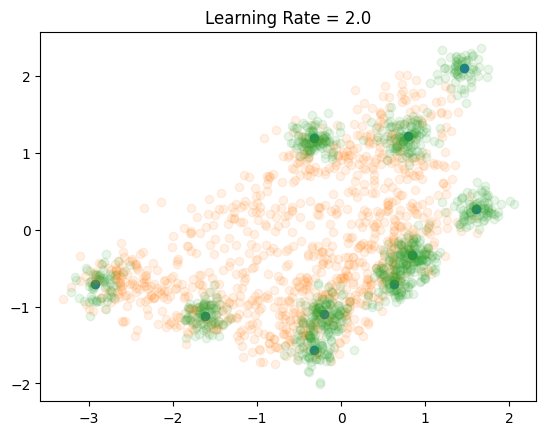

100%|██████████| 20000/20000 [00:15<00:00, 1319.27it/s]


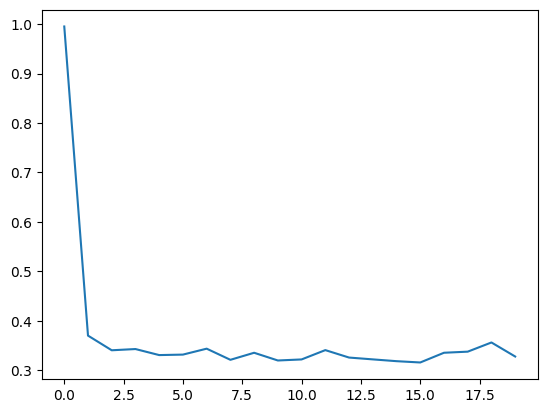

Start generating samples with nn...


100%|██████████| 100/100 [00:14<00:00,  6.92it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 130.86it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

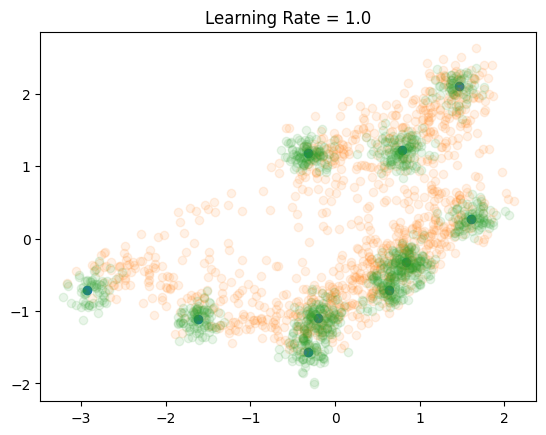

100%|██████████| 200000/200000 [02:29<00:00, 1334.64it/s]


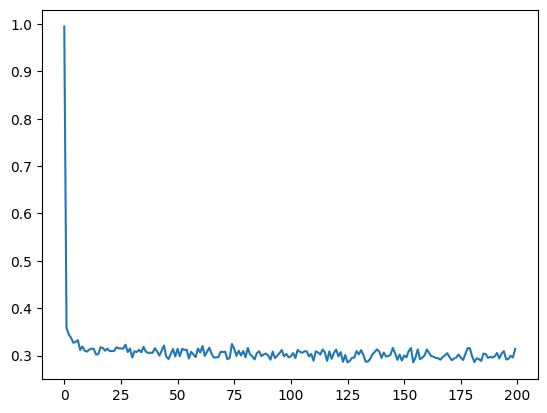

Start generating samples with nn...


100%|██████████| 100/100 [00:14<00:00,  6.68it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 127.55it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

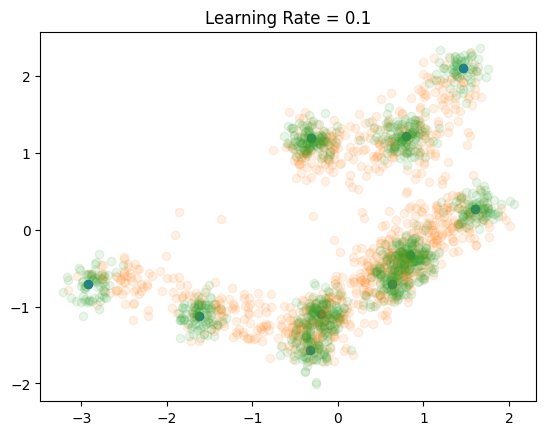

100%|██████████| 1000000/1000000 [12:36<00:00, 1322.50it/s]


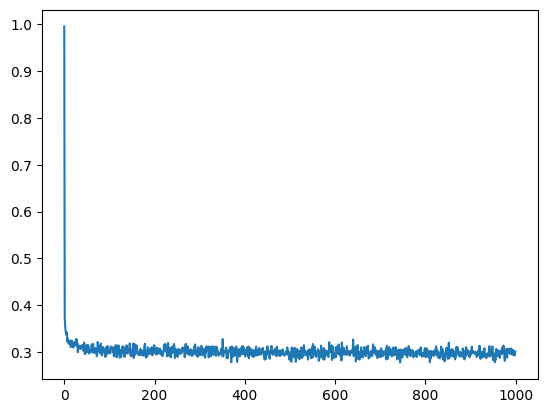

Start generating samples with nn...


100%|██████████| 100/100 [00:16<00:00,  6.14it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 122.35it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

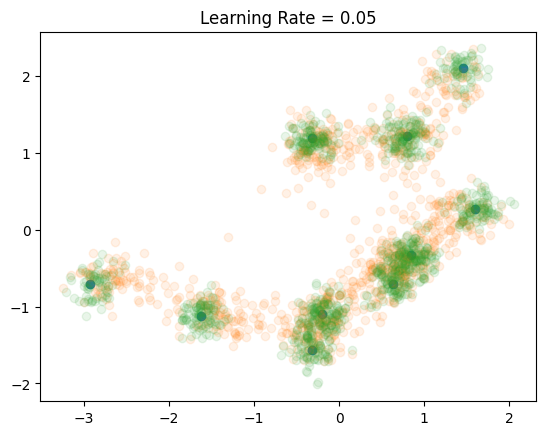

100%|██████████| 2000000/2000000 [25:18<00:00, 1317.07it/s]


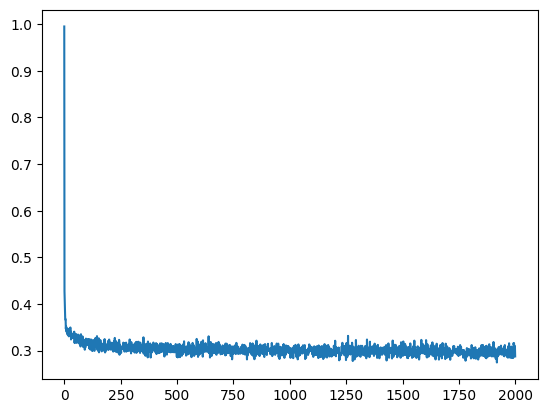

Start generating samples with nn...


100%|██████████| 100/100 [00:19<00:00,  5.04it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 121.45it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

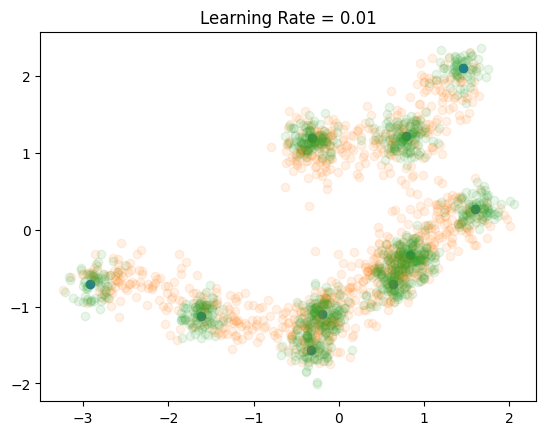

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
if rerun:
    key = random.key(0)
    subkeys = random.split(key, 3)
    delta = .01
    lr_list = [2., 1., 0.1, 0.05,  0.01]
    n_step_list = [20_000, 20_000, 200_000, 1_000_000, 2_000_000]
    exp_dict = {
        'dataset_size': 10,
        'batch_size': 5000,
        'm': 1000,
        'key': subkeys[0],
        'deviation': 2,
        'delta': delta
    }
    res_samples_list = []
    res_params_list = []
    for lr, n_steps in zip(lr_list, n_step_list):
        exp_dict['step_size'] = lr
        exp_dict['n_steps'] = n_steps
        loss_hist, params, dataset = training_loop_diffusion(**exp_dict)
        res_params_list.append({'params': params, 'lr': lr, 'dataset': dataset})
        plt.plot(loss_hist[::1000])
        plt.show()
        plt.clf()
        samples = generate_OU_nn(params, 1000, key = subkeys[1], delta=delta)
        plt.scatter(dataset[:, 0], dataset[:, 1])
        samples_optimal = generate_OU_optimal(dataset, 1000, delta=delta, key=subkeys[2])

        plt.scatter(samples[:, 0], samples[:, 1], alpha=.1, label='NN')
        plt.scatter(samples_optimal[:, 0], samples_optimal[:, 1], alpha=.1, label='Optimal')
        plt.title(f'Learning Rate = {lr}')
        plt.savefig(f'plot_samples_{lr}.pdf', format = 'pdf')
        files.download(f'plot_samples_{lr}.pdf')
        plt.show()
        res_samples_list.append(samples)
    with open('res_params_list.pkl', 'wb') as f:
        pickle.dump(res_params_list, f)

Start generating samples with nn...


100%|██████████| 100/100 [00:11<00:00,  8.69it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 108.00it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

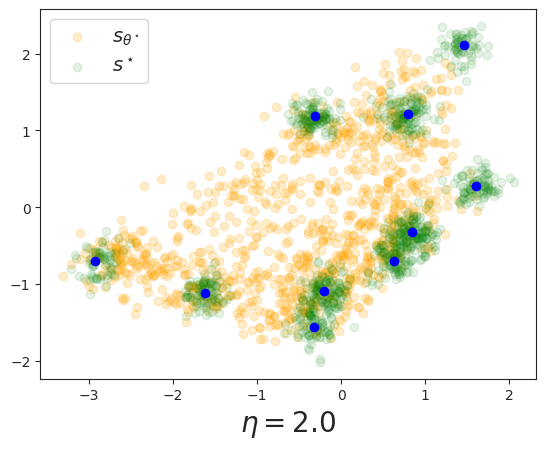

Start generating samples with nn...


100%|██████████| 100/100 [00:12<00:00,  8.03it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 98.98it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

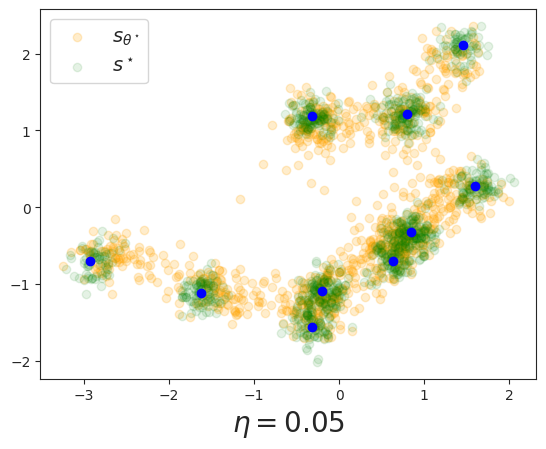

<Figure size 640x480 with 0 Axes>

In [ ]:
try:
    with open('res_params_list.pkl', 'rb') as f:
        res_params_list = pickle.load(f)
except Exception as e:
    print(f'Error occurred: {e}')
key = random.key(0)
subkeys = random.split(key, 3)
dataset = res_params_list[0]['dataset']
sample_list = []
sns.set_style('ticks')
for d in [res_params_list[0], res_params_list[-2]]:
    plt.rc('legend', fontsize=14)
    samples = generate_OU_nn(d['params'], 1000, key = subkeys[1], delta=.01)
    samples_optimal = generate_OU_optimal(dataset, 1000, delta=.01, key=subkeys[2])
    plt.scatter(samples[:, 0], samples[:, 1], alpha=.2, label=r'$s_{\theta^\star}$',
                c='orange')
    plt.scatter(samples_optimal[:, 0], samples_optimal[:, 1], alpha=.1, label=r'$s^\star$',
                c='green')

    plt.scatter(dataset[:, 0], dataset[:, 1], c='blue')
    # plt.title(f'Learning Rate = {d["lr"]}')
    plt.xlabel(r'$\eta = $'+f'{d["lr"]}', fontsize=20)
    plt.legend()
    plt.savefig(f'plot_samples_{d["lr"]}.pdf', format = 'pdf', bbox_inches='tight')
    files.download(f'plot_samples_{d["lr"]}.pdf')
    sample_list.append(samples)
    plt.show()
    plt.clf()

In [ ]:
if rerun:
    mean = jnp.mean(dataset, axis=0)
    cov = jnp.cov(dataset.T)
    print(mean.shape, cov.shape)
    samples_dict =  {'lr':[], 'w_dist_optimal': [], 'w_dist_true': [], 'samples': []}
    solve_fn = jax.jit(linear.solve)
    res_dict = {'lr': [], 'dist': []}
    for res in res_params_list:
        sample_subkeys = random.split(subkeys[2], 30)
        for k in range(10):
            samples = generate_OU_nn(res["params"], 1000, delta=delta, key=sample_subkeys[3*k])
            samples_true = random.multivariate_normal(sample_subkeys[3*k+1], mean, cov, shape=(1000, ))
            samples_optimal = generate_OU_optimal(dataset, 1000, delta=delta, key=subkeys[3*k+2])
            geom = pointcloud.PointCloud(samples, samples_optimal, epsilon=1e-6)
            ot = solve_fn(geom)
            print(f'nn_empirical: {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            samples_dict['w_dist_optimal'].append(float((ot.primal_cost + ot.dual_cost) / 2))
            geom = pointcloud.PointCloud(samples, samples_true, epsilon=1e-6)
            ot = solve_fn(geom)
            print(f'nn_true:      {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            samples_dict['w_dist_true'].append(float((ot.primal_cost + ot.dual_cost) / 2))
            samples_dict['samples'].append(samples)
            samples_dict['lr'].append(res['lr'])

(2,) (2, 2)
Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.73it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 50.05it/s]


nn_empirical: ot.primal_cost=0.087717, ot.dual_cost=0.093176
nn_true:      ot.primal_cost=0.026726, ot.dual_cost=0.26975
Start generating samples with nn...


...

nn_empirical: ot.primal_cost=0.015084, ot.dual_cost=0.01726
nn_true:      ot.primal_cost=0.027547, ot.dual_cost=0.26929
Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.67it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 54.27it/s]


nn_empirical: ot.primal_cost=0.013469, ot.dual_cost=0.015535
nn_true:      ot.primal_cost=0.032974, ot.dual_cost=0.29596


In [ ]:
if rerun:
    samples_dict['mmd_dist_optimal'] = []
    samples_dict['mmd_dist_true'] = []
    sample_subkeys = random.split(subkeys[2], 2*len(samples_dict['lr']))
    for k, (lr, sample) in enumerate(zip(samples_dict['lr'], samples_dict['samples'])):
        mean = jnp.mean(dataset, axis=0)
        cov = jnp.cov(dataset.T)
        print(f'{lr}')
        samples_true = random.multivariate_normal(sample_subkeys[k], mean, cov, shape=(1000, ))
        samples_optimal = generate_OU_optimal(dataset, 1000, delta=delta, key=subkeys[k+len(samples_dict['lr'])])
        dist2optimal = float(mmd(sample, samples_optimal, .1))
        dist2true = float(mmd(sample, samples_true, .1))
        print(f'{dist2optimal=:.5g}, {dist2true=:.5g}')
        samples_dict['mmd_dist_optimal'].append(dist2optimal)
        samples_dict['mmd_dist_true'].append(dist2true)

2.0
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:02<00:00, 39.16it/s]


dist2optimal=0.015679, dist2true=0.0032391
2.0
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:02<00:00, 40.51it/s]


dist2optimal=0.017508, dist2true=0.0030067
2.0
dimension=2
Start generating samples with optimal score...


...

dist2optimal=0.0070177, dist2true=0.0089735
0.01
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:02<00:00, 40.32it/s]


dist2optimal=0.0070866, dist2true=0.0088467
0.01
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:02<00:00, 40.64it/s]


dist2optimal=0.0067196, dist2true=0.010966


In [ ]:
if rerun:
    samples_dict['dataset'] = dataset
    with open('samples_dict.pkl', 'wb') as f:
        pickle.dump(samples_dict, f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
if not rerun:
    try:
        with open('samples_dict.pkl', 'rb') as f:
            samples_dict = pickle.load(f)
    except Exception:
        pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

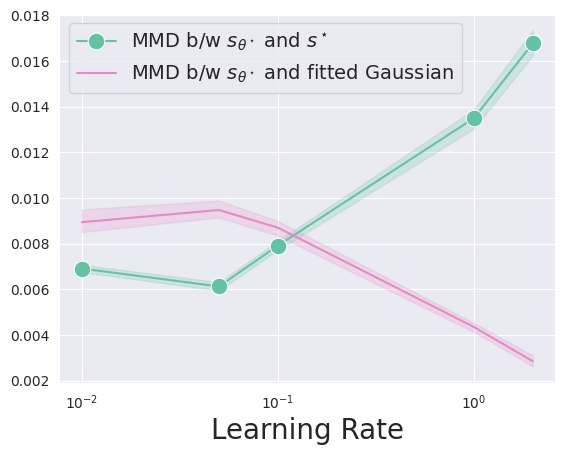

In [ ]:
df = pd.DataFrame(samples_dict['mmd_dist_optimal'])
df['mmd_dist_true'] = pd.Series(samples_dict['mmd_dist_true'])
df['lr'] = pd.Series(samples_dict['lr'])
sns.set_style('darkgrid')
sns.lineplot(data=df, x='lr', y='mmd_dist_optimal', marker='o', c = sns.color_palette("Set2")[0],
             label=r'MMD b/w $s_{\theta^\star}$ and $s^\star$', markersize=12)
sns.lineplot(data=df, x='lr', y='mmd_dist_true', c=sns.color_palette("Set2")[3],
             label = r'MMD b/w $s_{\theta^\star}$ and fitted Gaussian')
plt.xlabel('Learning Rate', fontsize=20)
plt.ylabel('')
plt.legend(fontsize=14)
plt.xscale('log')
plt.savefig('plot_mmd.pdf', format = 'pdf', bbox_inches='tight')
files.download('plot_mmd.pdf')
plt.show()

Dimension: 2
Simulation: 1


100%|██████████| 50000/50000 [00:38<00:00, 1309.19it/s]


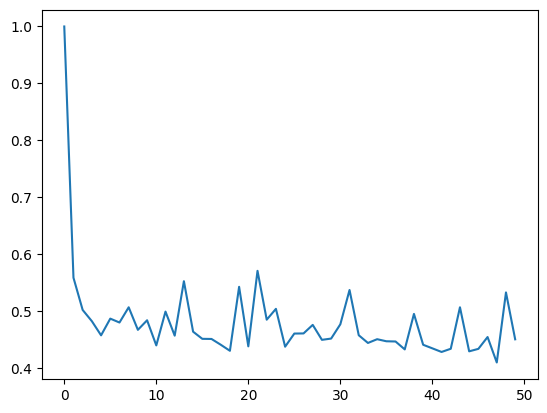

Dimension: 2
Simulation: 2


100%|██████████| 50000/50000 [00:38<00:00, 1293.48it/s]


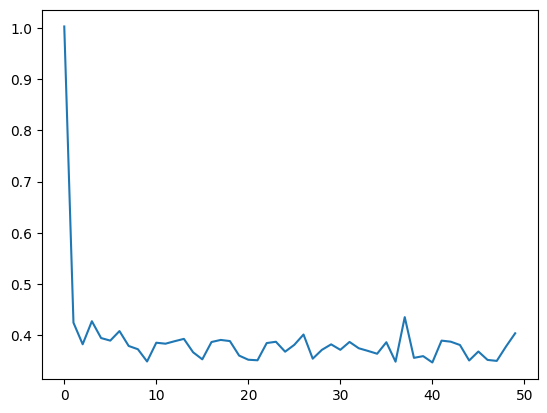

Dimension: 2
Simulation: 3


100%|██████████| 50000/50000 [00:37<00:00, 1339.87it/s]


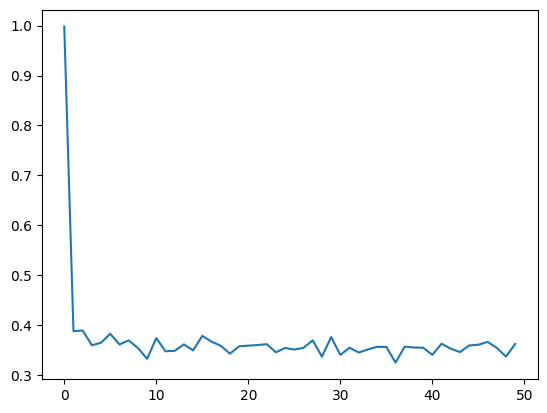

Dimension: 5
Simulation: 1


100%|██████████| 50000/50000 [00:38<00:00, 1288.85it/s]


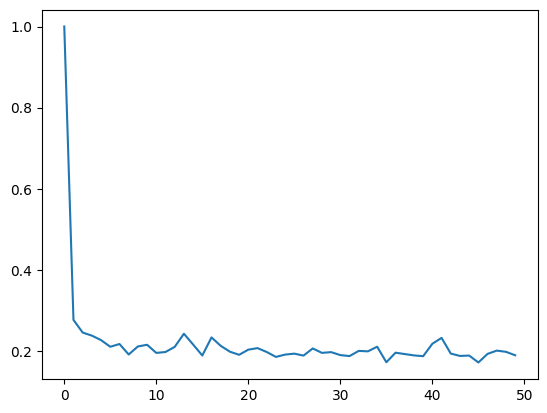

Dimension: 5
Simulation: 2


100%|██████████| 50000/50000 [00:37<00:00, 1321.55it/s]


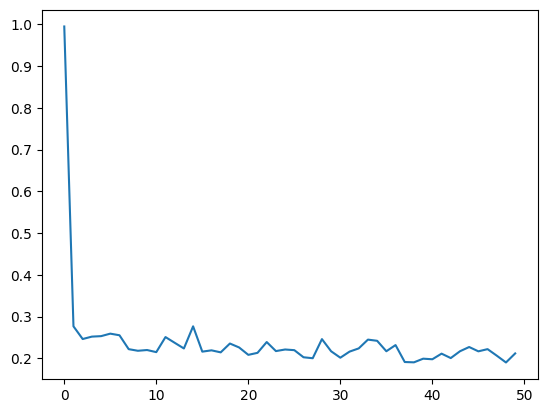

Dimension: 5
Simulation: 3


100%|██████████| 50000/50000 [00:38<00:00, 1296.09it/s]


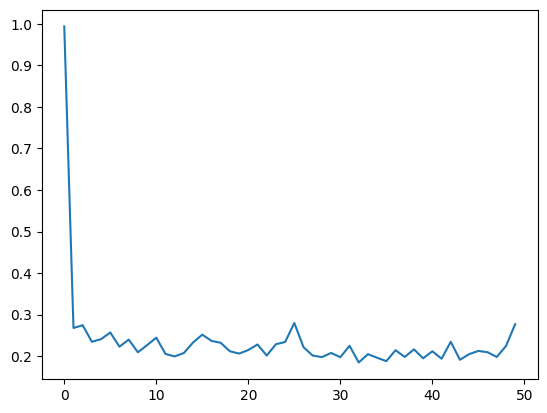

Dimension: 10
Simulation: 1


100%|██████████| 50000/50000 [00:38<00:00, 1308.20it/s]


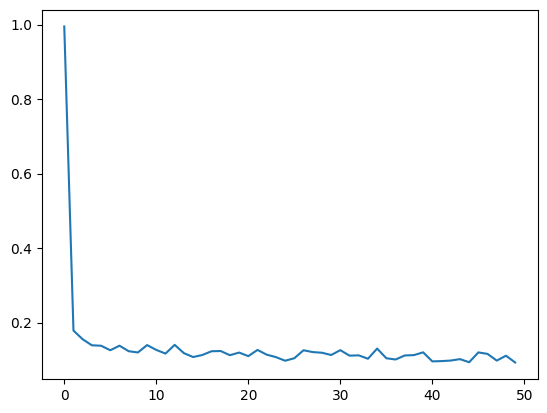

Dimension: 10
Simulation: 2


100%|██████████| 50000/50000 [00:38<00:00, 1303.02it/s]


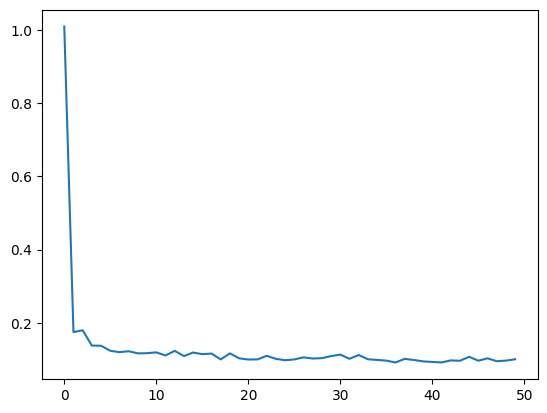

Dimension: 10
Simulation: 3


100%|██████████| 50000/50000 [00:37<00:00, 1336.67it/s]


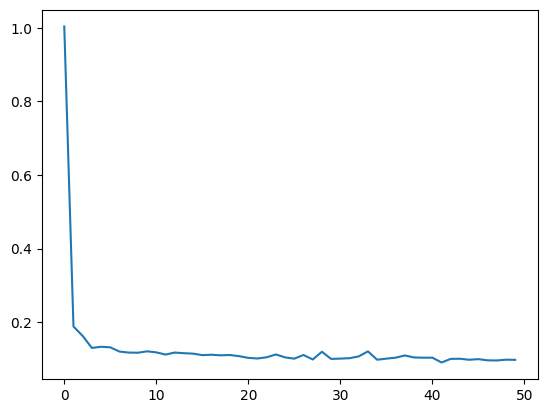

Dimension: 50
Simulation: 1


100%|██████████| 50000/50000 [00:39<00:00, 1262.29it/s]


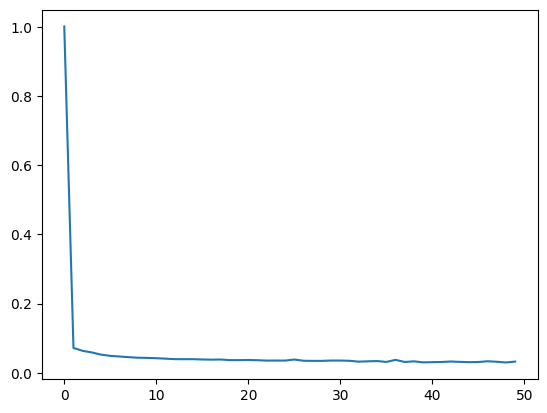

Dimension: 50
Simulation: 2


100%|██████████| 50000/50000 [00:38<00:00, 1289.19it/s]


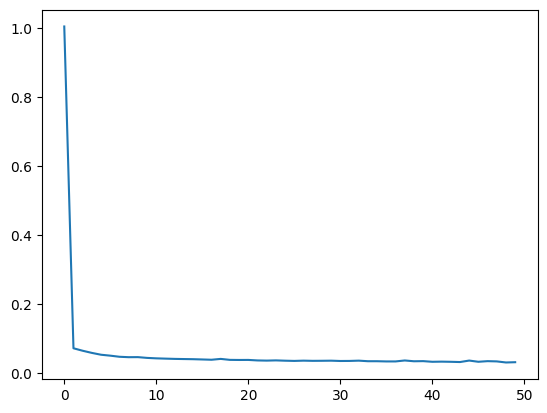

Dimension: 50
Simulation: 3


100%|██████████| 50000/50000 [00:39<00:00, 1273.62it/s]


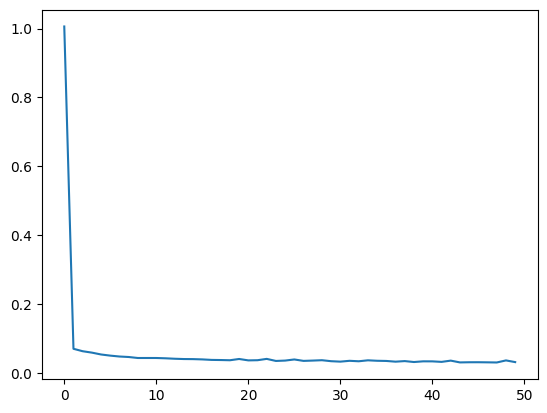

Dimension: 80
Simulation: 1


100%|██████████| 50000/50000 [00:38<00:00, 1296.28it/s]


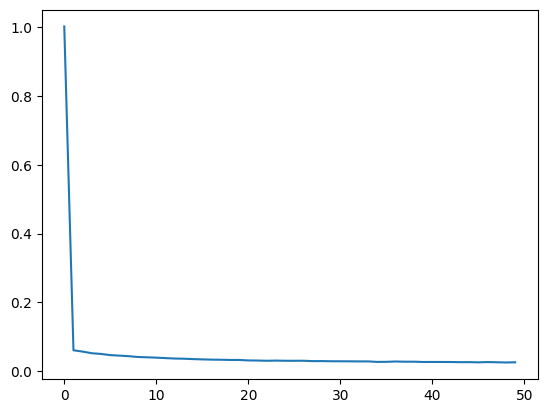

Dimension: 80
Simulation: 2


100%|██████████| 50000/50000 [00:39<00:00, 1264.89it/s]


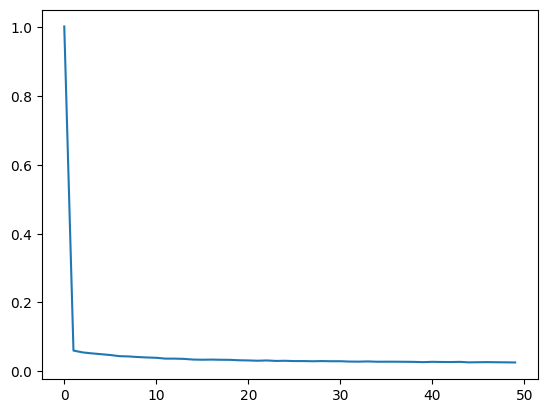

Dimension: 80
Simulation: 3


100%|██████████| 50000/50000 [00:38<00:00, 1298.35it/s]


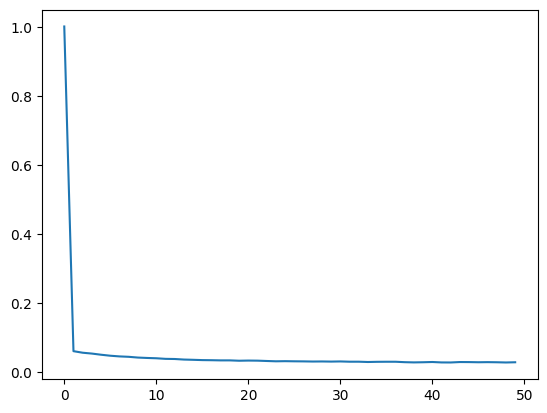

Dimension: 100
Simulation: 1


100%|██████████| 50000/50000 [00:41<00:00, 1199.24it/s]


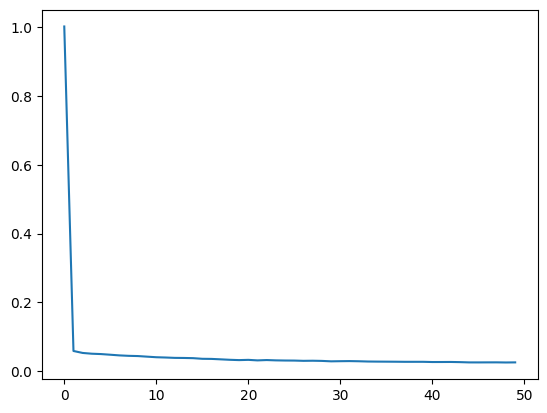

Dimension: 100
Simulation: 2


100%|██████████| 50000/50000 [00:41<00:00, 1192.12it/s]


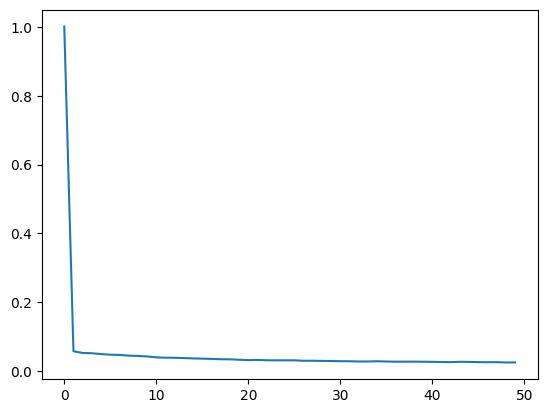

Dimension: 100
Simulation: 3


100%|██████████| 50000/50000 [00:41<00:00, 1201.58it/s]


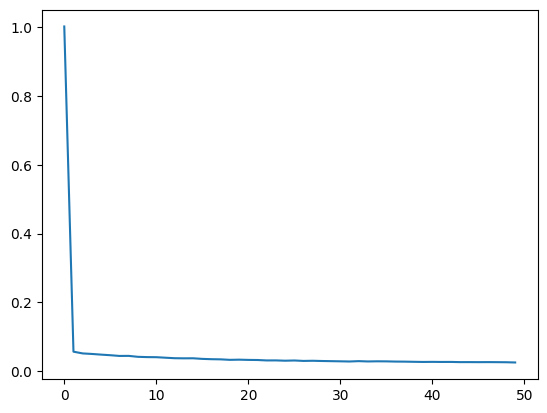

Dimension: 200
Simulation: 1


100%|██████████| 50000/50000 [00:50<00:00, 997.07it/s] 


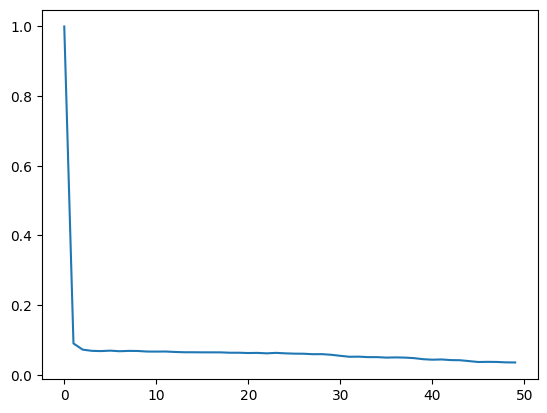

Dimension: 200
Simulation: 2


100%|██████████| 50000/50000 [00:50<00:00, 997.99it/s]


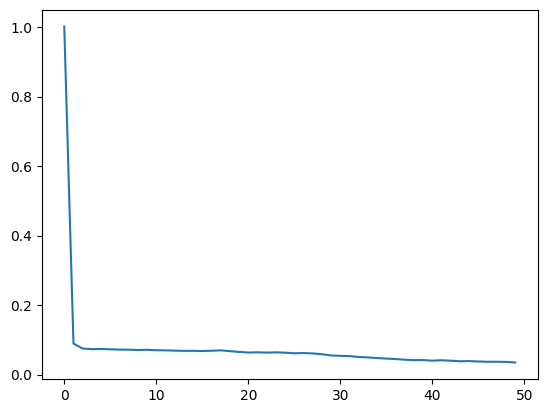

Dimension: 200
Simulation: 3


100%|██████████| 50000/50000 [00:50<00:00, 994.03it/s] 


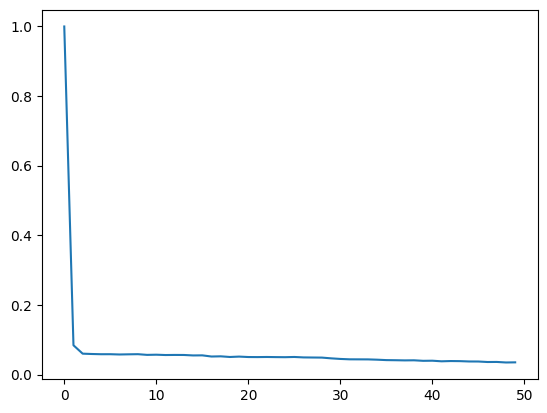

Dimension: 400
Simulation: 1


100%|██████████| 50000/50000 [01:32<00:00, 539.32it/s]


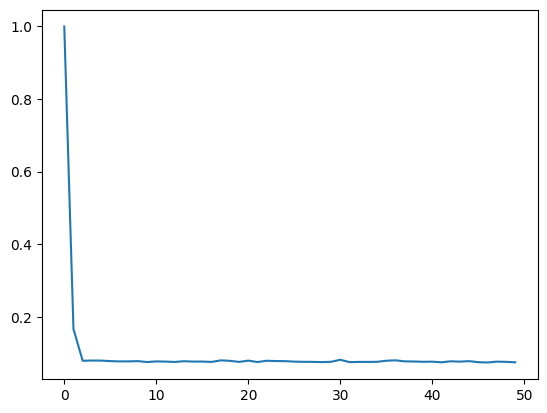

Dimension: 400
Simulation: 2


100%|██████████| 50000/50000 [01:32<00:00, 538.17it/s]


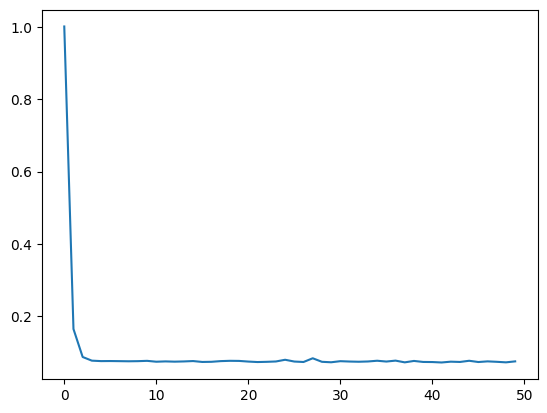

Dimension: 400
Simulation: 3


100%|██████████| 50000/50000 [01:32<00:00, 537.66it/s]


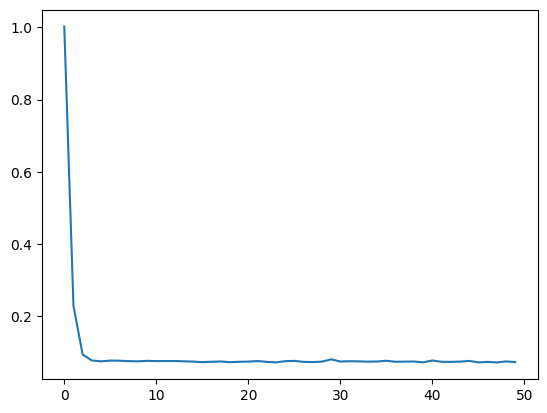

Dimension: 1000
Simulation: 1


100%|██████████| 50000/50000 [03:05<00:00, 269.30it/s]


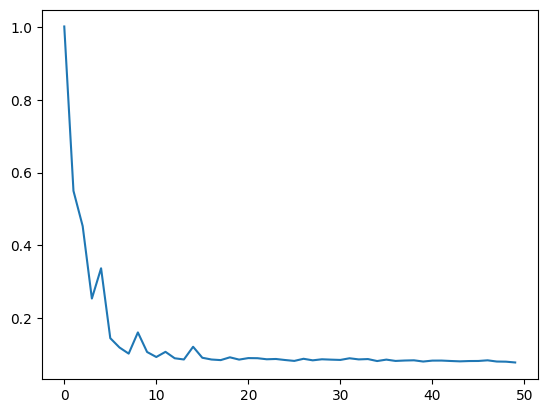

Dimension: 1000
Simulation: 2


100%|██████████| 50000/50000 [02:53<00:00, 287.60it/s]


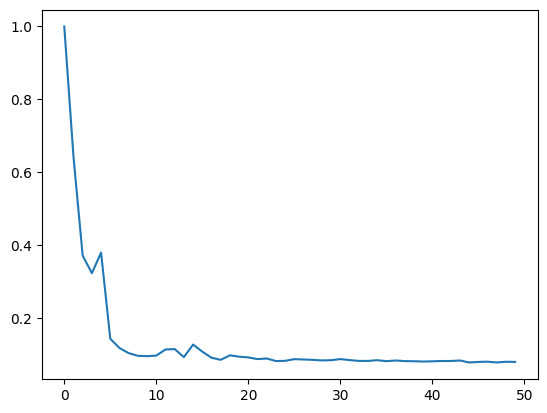

Dimension: 1000
Simulation: 3


100%|██████████| 50000/50000 [02:53<00:00, 287.81it/s]


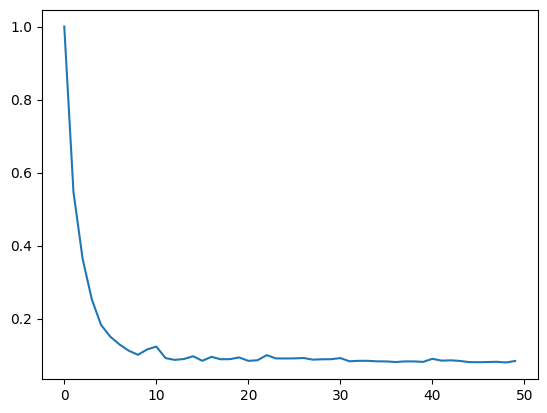

In [ ]:
if rerun:
    key = random.key(42)
    delta = 0.01
    dim_list = [2, 5, 10, 50, 80, 100, 200, 400, 1000]
    dim_subkeys = random.split(key, len(dim_list))
    dist_list = []
    num_simulations = 3
    for i, d in enumerate(dim_list):
        subkeys = random.split(dim_subkeys[i], num_simulations)
        for k in range(num_simulations):
            print(f'Dimension: {d}')
            print(f'Simulation: {k+1}')
            res = []
            exp_dict_small_step = {
                'dataset_size': 10,
                'batch_size': 5000,
                'step_size': 0.5,
                'm': 1000,
                'n_steps': 50_000,
                'key': subkeys[k],
                'deviation': 2,
                'd': d,
                'delta': delta
            }
            loss_hist_small_step, params_small_step, dataset = training_loop_diffusion(**exp_dict_small_step)
            plt.plot(loss_hist_small_step[::1000])
            # plt.savefig(f'loss_hist_small_step_{d}.pdf', format = 'pdf')
            plt.show()
            res_dict = {
                'lr': exp_dict_small_step['step_size'],
                'delta': delta,
                'dim': d,
                'samples_small_step': params_small_step,
                'dataset': dataset,
            }
            dist_list.append(res_dict)

In [ ]:
if rerun:
    key = random.key(0)
    subkeys_dim = random.split(key, len(dist_list))
    for i, d in enumerate(dist_list):
        print(f'Dimension = {d["dim"]}')
        d["samples"] = []
        subkeys = random.split(subkeys_dim[i], 3)
        for j in range(5):
            samples_nn = generate_OU_nn(d["samples_small_step"], 1000, delta=delta, key=subkeys[j])
            d["samples"].append(samples_nn)

Dimension = 2
Start generating samples with nn...


100%|██████████| 100/100 [00:16<00:00,  5.89it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:16<00:00,  6.09it/s]


Start generating samples with nn...


...

100%|██████████| 100/100 [00:16<00:00,  6.21it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:15<00:00,  6.26it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:15<00:00,  6.26it/s]


In [ ]:
if rerun:
    with open(f'dist_list_{dist_list[0]["lr"]}.pkl', 'wb') as f:
        pickle.dump(dist_list, f)
    files.download(f'dist_list_{dist_list[0]["lr"]}.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
if not rerun:
    try:
        with open('dist_list_0.5.pkl', 'rb') as f:
            dist_list = pickle.load(f)
    except Exception:
        pass

In [ ]:
res_dict_mmd_high_dim = compute_dist(dist_list, h = 1)

Dimension = 2
Round 1
Distance to true distribution:    0.062096
Distance to optimal distribution: 0.044027
Distance true to optimal:         0.076201
Round 2
Distance to true distribution:    0.05606
Distance to optimal distribution: 0.039685
Distance true to optimal:         0.070808
Round 3
Distance to true distribution:    0.052887
Distance to optimal distribution: 0.037695
Distance true to optimal:         0.068442
Round 4
Distance to true distribution:    0.051502
Distance to optimal distribution: 0.038304
Distance true to optimal:         0.067125
Round 5
Distance to true distribution:    0.055796
Distance to optimal distribution: 0.038678
Distance true to optimal:         0.06955
Dimension = 2
Round 1
Distance to true distribution:    0.10884
Distance to optimal distribution: 0.041732
Distance true to optimal:         0.093839
Round 2
Distance to true distribution:    0.09877
Distance to optimal distribution: 0.036346
Distance true to optimal:         0.090189
Round 3
Distance 

<ipython-input-14-8d84c6d01849>:26: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(


Distance to true distribution:    0.072663
Distance to optimal distribution: 0.024842
Distance true to optimal:         0.089646
Round 2
Distance to true distribution:    0.067511
Distance to optimal distribution: 0.026483
Distance true to optimal:         0.088445
Round 3
Distance to true distribution:    0.069233
Distance to optimal distribution: 0.025762
Distance true to optimal:         0.09021
Round 4
Distance to true distribution:    0.068404
Distance to optimal distribution: 0.025173
Distance true to optimal:         0.088415
Round 5
Distance to true distribution:    0.067168
Distance to optimal distribution: 0.025792
Distance true to optimal:         0.088888
Dimension = 5
Round 1
Distance to true distribution:    0.065532
Distance to optimal distribution: 0.039719
Distance true to optimal:         0.082451
Round 2
Distance to true distribution:    0.062912
Distance to optimal distribution: 0.040032
Distance true to optimal:         0.081131
Round 3
Distance to true distributio

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

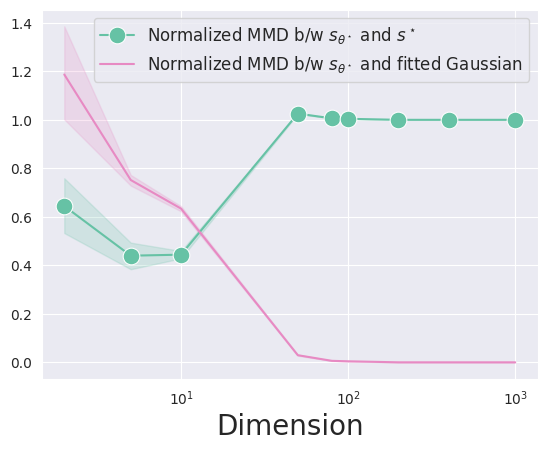

In [ ]:
df = pd.DataFrame(res_dict_mmd_high_dim)
prop = True
sns.set_style('darkgrid')
if prop:
    sns.lineplot(data=df, x='dim', y='dist_optimal_proportion', c=sns.color_palette("Set2")[0],
                 marker='o', label = r'Normalized MMD b/w $s_{\theta^\star}$ and $s^\star$',
                 markersize=12)
    sns.lineplot(data=df, x='dim', y='dist_true_proportion', c=sns.color_palette("Set2")[3],
                 label = r'Normalized MMD b/w $s_{\theta^\star}$ and fitted Gaussian')
else:
    sns.lineplot(data=df, x='dim', y='dist_optimal', label='Distance to optimal distribution')
    sns.lineplot(data=df, x='dim', y='dist_true', label = 'Distance to true distribution')
    sns.lineplot(data=df, x='dim', y='true_optimal', label = 'Disance between true and optimal distribution')
# sns.lineplot(data=df, x='dim', y='true_optimal', label = 'MMD between true and optimal distribution')
# sns.lineplot(data=df, x='dim', y='true_optimal', label = 'MMD between true and optimal distribution')
plt.legend(fontsize=12)
plt.xlabel('Dimension', fontsize=20)
plt.ylabel('')
plt.xscale('log')
# plt.yscale('log')
filename = 'plot_mmd_high_dim'
if prop:
    filename += '_proportion'
plt.savefig(f'{filename}_{dist_list[0]["lr"]}.pdf', format = 'pdf', bbox_inches='tight')
files.download(f'{filename}_{dist_list[0]["lr"]}.pdf')
plt.show()

2
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 117.15it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

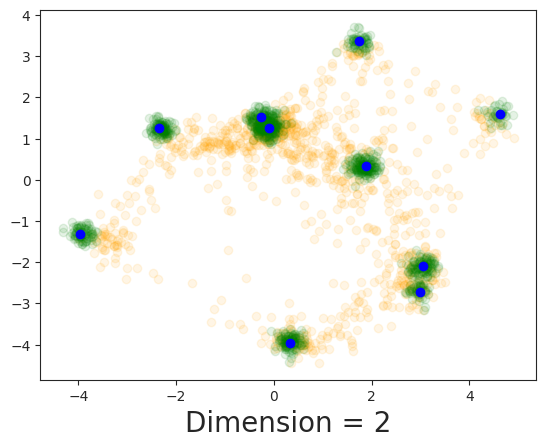

5
dimension=5
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 114.25it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

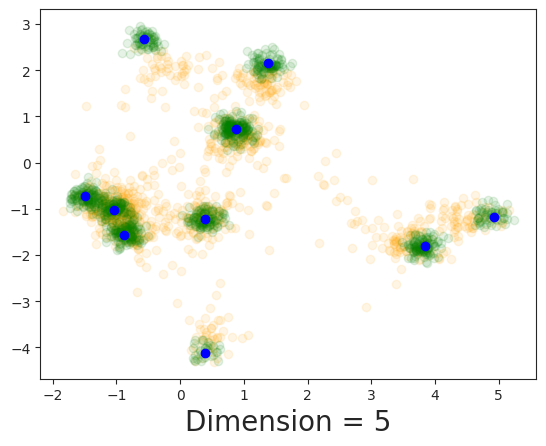

10
dimension=10
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 112.08it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

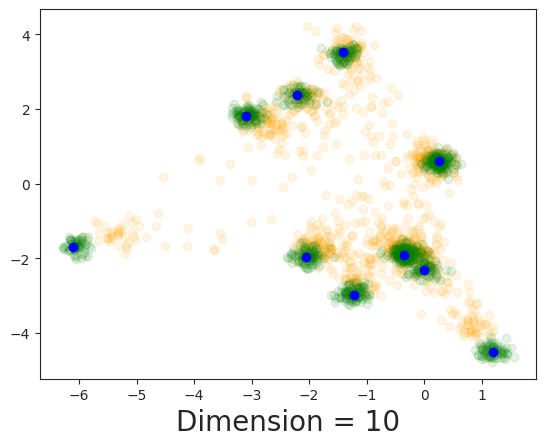

50
dimension=50
Start generating samples with optimal score...


100%|██████████| 100/100 [00:00<00:00, 100.97it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

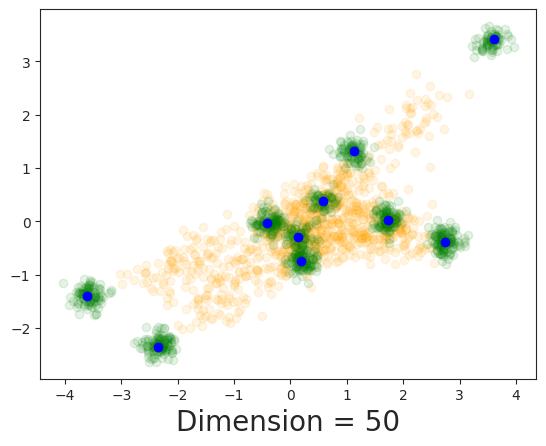

80
dimension=80
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 93.17it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

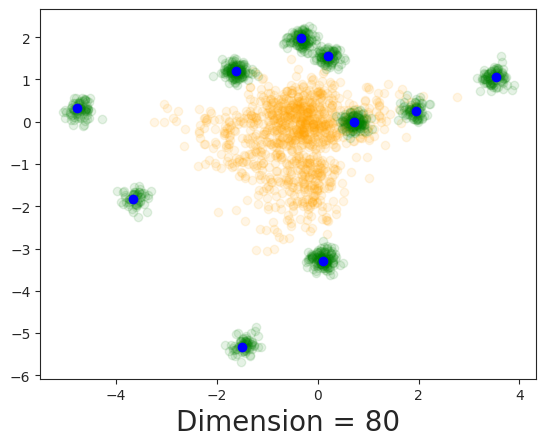

100
dimension=100
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 89.06it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

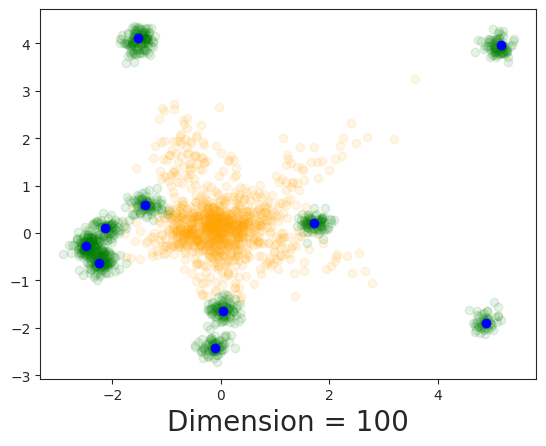

200
dimension=200
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 79.82it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

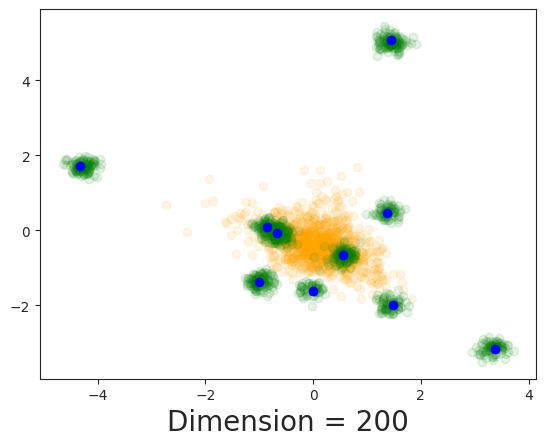

400
dimension=400
Start generating samples with optimal score...


100%|██████████| 100/100 [00:02<00:00, 39.44it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

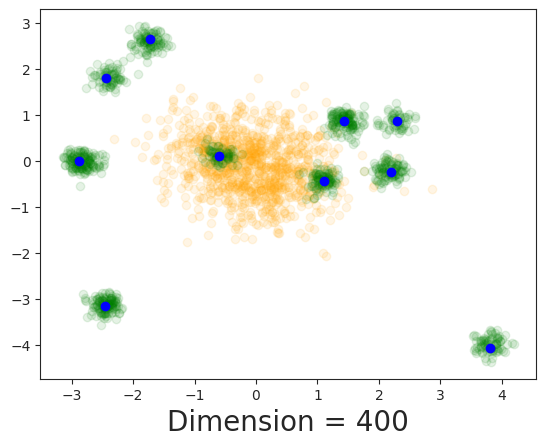

1000
dimension=1000
Start generating samples with optimal score...


100%|██████████| 100/100 [00:08<00:00, 12.16it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

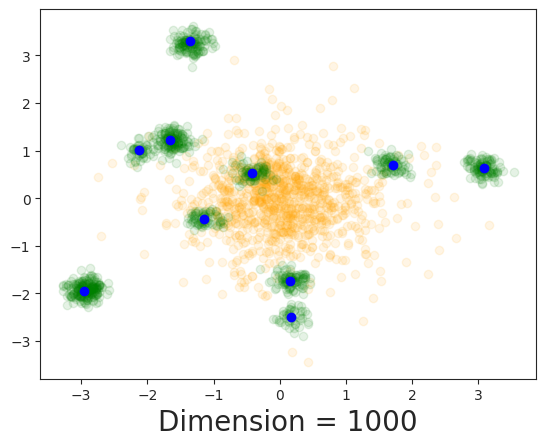

In [ ]:
sns.set_style('ticks')
key = random.key(0)
subkeys = random.split(key, 100)
for i, d in enumerate(dist_list[::3]):
    print(d['dim'])
    # s = generate_OU_optimal(d["dataset"], 1000, 0.01, key = subkeys[i])
    # plt.scatter(s[:, 0], s[:, 1], alpha=.1, c='orange')
    plt.scatter(d["samples"][0][:, 0], d["samples"][0][:, 1], alpha=.1, c='orange')
    # plt.scatter(s[:, 0], s[:, 1], alpha=.1, c='green')
    plt.scatter(d["dataset"][:, 0], d["dataset"][:, 1], c='blue')
    plt.xlabel(f'Dimension = {d["dim"]}', fontsize=20)
    plt.savefig(f'plot_samples_{d["dim"]}.pdf', format = 'pdf', bbox_inches='tight')
    files.download(f'plot_samples_{d["dim"]}.pdf')
    plt.show()